##### AlexNet Architecture

In [14]:
# !unzip dataset.zip

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt


In [16]:
train_dir = 'alexnet-dataset/train'
test_dir = 'alexnet-dataset/test'

##### Data Augmentation and Preprocessing

In [17]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150,150),
    batch_size = 32,
    class_mode = 'categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (150,150),
    batch_size = 32,
    class_mode = 'categorical'
)



Found 1275 images belonging to 2 classes.


Found 182 images belonging to 2 classes.


In [18]:
model = Sequential()

# Layer 1: Convolutional + MaxPooling
model.add(Conv2D(96,(11,11),strides=(4,4),activation='relu',input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(3,3),strides=(2,2)))

# Layer 3: Convolutional + MaxPooling
model.add(Conv2D(256,(5,5),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(3,3),strides=(2,2)))

# Layer 3: Convolutional 
model.add(Conv2D(384,(3,3),activation='relu',padding='same'))

# Layer 4: Convolutional 
model.add(Conv2D(384,(3,3),activation='relu',padding='same'))


# Layer 5: Convolutional + MaxPooling
model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(MaxPool2D(pool_size=(3,3),strides=(2,2)))

# Flatten the output for the Fully Connected Layers
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))

# Fully Conncted Layer 2
model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))


# Output Layer
model.add(Dense(train_generator.num_classes,activation='sigmoid'))

/home/bhupen/miniconda3/envs/classification-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 35, 35, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 35, 35, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 17, 17, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 17, 17, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,979,394 (114.36 MB)

 Trainable params: 29,978,690 (114.36 MB)

 Non-trainable params: 704 (2.75 KB)

##### Model Compilation & Training

In [20]:
# Compile the model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# Train the model
history = model.fit(train_generator,
                    epochs=20,
                    validation_data = test_generator)

/home/bhupen/miniconda3/envs/classification-env/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 943ms/step - accuracy: 0.5616 - loss: 2.5360 - val_accuracy: 0.4286 - val_loss: 0.8811
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 919ms/step - accuracy: 0.6361 - loss: 0.6672 - val_accuracy: 0.6154 - val_loss: 0.6501
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 965ms/step - accuracy: 0.6416 - loss: 0.6397 - val_accuracy: 0.6099 - val_loss: 0.6420
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 906ms/step - accuracy: 0.7412 - loss: 0.5577 - val_accuracy: 0.6264 - val_loss: 0.6981
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 910ms/step - accuracy: 0.7929 - loss: 0.4803 - val_accuracy: 0.6593 - val_loss: 0.5807
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 912ms/step - accuracy: 0.7600 - loss: 0.5275 - val_accuracy: 0.6978 - val_loss: 0.5589
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 915ms/step - accuracy: 0.7788 - loss: 0.5027 - val_accuracy: 0.6154 - val_loss: 0.5999
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 902ms/step - accuracy: 0.7655 - loss: 0.5142 - val_accu

In [24]:
# Evaluate the model
test_loss,test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7857 - loss: 0.4662
Test accuracy: 0.7857142686843872


In [25]:
# Save the model
model.save('alexnet_custom_dataset_model.h5')

##### Visualizing Loss and Accuracy

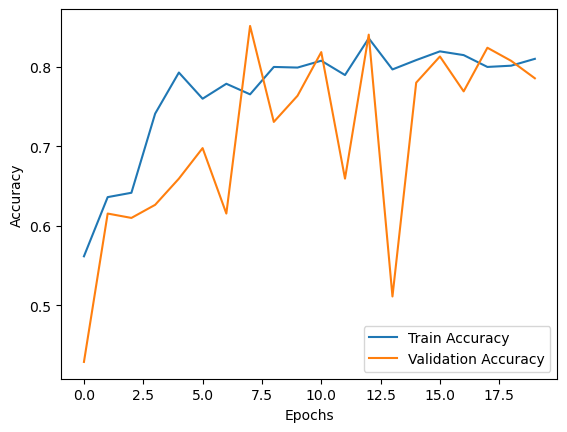

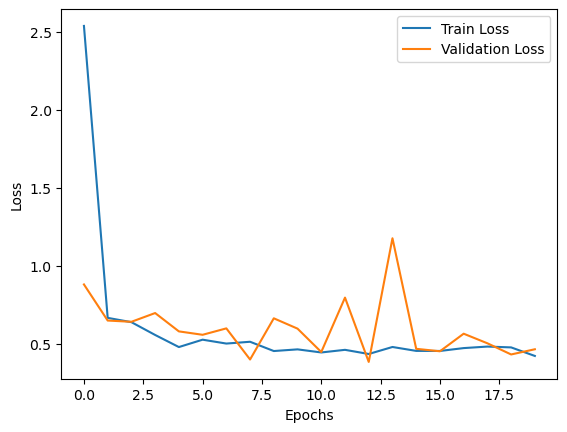

In [26]:
# Visualize  Training History
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

##### Inferencing and Prediction

In [37]:
import numpy as np

# Prediction 
def predict_image(model,image_path,class_names):
    from tensorflow.keras.utils import load_img,img_to_array

    # Load the image
    img = load_img(image_path,target_size=(150,150))
    img_array = img_to_array(img) / 255.0 # Normalize the image
    img_array = np.expand_dims(img_array,axis=0)

    # Predict the class Probabilites
    prediction = model.predict(img_array)

    # Get the index of the class with the highest probabilities
    predicted_class_index = np.argmax(prediction[0])

    # Get the predicted class name
    predicted_class = class_names[predicted_class_index]

    return predicted_class


In [40]:
class_name = ['daisy','dandelion']
predicted_class = predict_image(model,image_path='alexnet-dataset/test/daisy/1392131677_116ec04751_jpg.rf.da99f9bb579ee96dc1728545ca519d6f.jpg',class_names=class_name)
print(f"Predicted Class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Class: daisy
